# Notebook 03 — Validación de residuales y ajuste con t-Student si rechaza normalidad

En esta etapa se evalúan las propiedades estadísticas de los residuales obtenidos del modelo de Alaton. El objetivo es verificar si el componente estocástico cumple supuestos de:
- media cercana a cero,
- ausencia de autocorrelación,
- y normalidad.

La validación es importante porque muchos modelos climáticos asumen errores Gaussianos. Sin embargo, en datos reales es común encontrar:
- colas pesadas,
- asimetrías,
- y eventos extremos.

En caso de rechazar normalidad, se considera una distribución t-Student para representar mejor la probabilidad de eventos extremos climáticos.

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

In [ ]:
# =========================================================
# IMPORTAR LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# LEER DATOS
# =========================================================

df = pd.read_excel('../data/simulated_climate_rice_2000_2025.xlsx')

# =========================================================
# PREPARAR VARIABLES
# =========================================================

# Convertir fecha
df['Date'] = pd.to_datetime(df['Date'])

# Crear índice temporal
df['t'] = range(len(df))

# Calcular temperatura promedio usando Tmax y Tmin
df['T_avg'] = (
    df['Temperature_Max_C']
    + df['Temperature_Min_C']
) / 2

# =========================================================
# COMPONENTE ESTACIONAL
# =========================================================

# Crear componente seno
df['sin'] = np.sin(2 * np.pi * df['t'] / 365)

# Crear componente coseno
df['cos'] = np.cos(2 * np.pi * df['t'] / 365)

# =========================================================
# AJUSTE MODELO ALATON
# =========================================================

# Variable dependiente
y = df['T_avg']

# Variables explicativas
X = df[['t', 'sin', 'cos']]

# Agregar intercepto
X = sm.add_constant(X)

# Ajustar OLS
model = sm.OLS(y, X).fit()

# =========================================================
# OBTENER RESIDUALES
# =========================================================

# Temperatura ajustada
df['seasonal_fit'] = model.predict(X)

# Residuales
df['residuals'] = (
    df['T_avg']
    - df['seasonal_fit']
)

# =========================================================
# DATAFRAME FINAL PARA VALIDACIÓN
# =========================================================

temp = df.copy()

In [ ]:
# =========================================================
# HISTOGRAMA DE RESIDUALES
# =========================================================

plt.figure(figsize=(10,5))

plt.hist(
    temp['residuals'],
    bins=50
)

plt.xlabel('Residual')
plt.ylabel('Frecuencia')

plt.title('Distribución de Residuales')

plt.show()

In [ ]:
# =========================================================
# QQ-PLOT PARA NORMALIDAD
# =========================================================

stats.probplot(
    temp['residuals'],
    dist="norm",
    plot=plt
)

plt.title('QQ-Plot de Residuales')

plt.show()

In [ ]:
# =========================================================
# TEST DE JARQUE-BERA
# =========================================================

jb_stat, jb_pvalue = stats.jarque_bera(
    temp['residuals']
)
# Imprimir resultados y comentar sobre normalidad
print("Jarque-Bera Statistic:", jb_stat)
print("p-value:", jb_pvalue)

# Interpretación del test Jarque-Bera
if jb_pvalue > 0.05:
    print("No se rechaza la hipótesis de normalidad.")
else:
    print("Se rechaza la hipótesis de normalidad.")

In [ ]:
# =========================================================
# TEST DE SHAPIRO-WILK
# =========================================================
# Se toma una muestra porque Shapiro no funciona
# bien con datasets demasiado grandes

sample_res = temp['residuals'].sample(
    5000,
    random_state=42
)

shapiro_stat, shapiro_pvalue = stats.shapiro(
    sample_res
)

# Imprimir resultados y comentar sobre normalidad
print("Shapiro Statistic:", shapiro_stat)
print("p-value:", shapiro_pvalue)

# Interpretación del test Shapiro-Wilk
if shapiro_pvalue > 0.05:
    print("No se rechaza la hipótesis de normalidad.")
else:
    print("Se rechaza la hipótesis de normalidad.")

In [ ]:
# =========================================================
# AUTOCORRELACIÓN DE RESIDUALES
# =========================================================

plot_acf(
    temp['residuals'],
    lags=40
)

plt.title('ACF de Residuales')

plt.show()

In [ ]:
# =========================================================
# AJUSTE t-STUDENT
# =========================================================
# Se estima una distribución t-Student para capturar
# posibles colas pesadas en los residuales.

t_params = stats.t.fit(
    temp['residuals']
)

df_t, loc_t, scale_t = t_params

print("Degrees of freedom:", df_t)
print("Location:", loc_t)
print("Scale:", scale_t)

In [ ]:
# =========================================================
# COMPARACIÓN NORMAL vs t-STUDENT
# =========================================================

x = np.linspace(
    temp['residuals'].min(),
    temp['residuals'].max(),
    500
)

normal_pdf = stats.norm.pdf(
    x,
    loc=temp['residuals'].mean(),
    scale=temp['residuals'].std()
)

t_pdf = stats.t.pdf(
    x,
    df=df_t,
    loc=loc_t,
    scale=scale_t
)

plt.figure(figsize=(10,5))

# Histograma
plt.hist(
    temp['residuals'],
    bins=50,
    density=True,
    alpha=0.5,
    label='Residuales'
)

# Normal con linea roja para destacar diferencias
plt.plot(
    x,
    normal_pdf,
    label='Normal',
    color='red'
)

# t-Student entrecortado para destacar diferencias en azul
plt.plot(
    x,
    t_pdf,
    label='t-Student',
    linestyle='--',
    color='blue'
)

plt.title('Ajuste de Distribuciones sobre Residuales')

plt.xlabel('Residual')
plt.ylabel('Densidad')

plt.legend()

plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [13]:
# Leer el excel
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

# Renombrar columnas para ajustar a formato requerido
df.rename(
    columns={
        't_min': 'Temperature_Min_C',
        't_max': 'Temperature_Max_C',
        'precip': 'Precipitation_mm',
        'date': 'Date',
        "t_mean": "Temperature_Avg_C",
    },
    inplace=True,
)

# 1. Asegurar que la columna de fecha sea datetime desde el inicio
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filtrar los departamentos seleccionando solo las columnas requeridas y definiendo la fecha como índice
columnas_interes = ['Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C', 'Precipitation_mm']

df_Casanare = df[df['department'] == 'Casanare'].set_index('Date')[columnas_interes].copy()
df_Tolima   = df[df['department'] == 'Tolima'].set_index('Date')[columnas_interes].copy()

# 3. Ver primeros registros 
print("--- Casanare ---")
print(df_Casanare.head())

print("\n--- Tolima ---")
print(df_Tolima.head())

--- Casanare ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.603952          21.207903                0.0   
2010-01-02          10.214985          20.429970                0.0   
2010-01-03          10.164834          20.329667                0.0   
2010-01-04          10.570606          21.141212                0.0   
2010-01-05          10.787858          21.575716                0.0   

            Precipitation_mm  
Date                          
2010-01-01               0.0  
2010-01-02               0.0  
2010-01-03               0.0  
2010-01-04               0.0  
2010-01-05               0.0  

--- Tolima ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.337388          19.954775               0.72   
2010-01-02           9.932993          


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES: CASANARE

[1] Pruebas Estadísticas de Normalidad:
  - Jarque-Bera: Estadístico = 21751.8787, p-valor = 0.0000e+00
  - Shapiro-Wilk: Estadístico = 0.8160, p-valor = 3.2408e-63

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales climáticos presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos:
  - Ajuste Normal:    mu = 0.0000, sigma = 4.6920
  - Ajuste t-Student: df (Grados de libertad) = 1.79, loc = -1.2347, scale = 2.0889


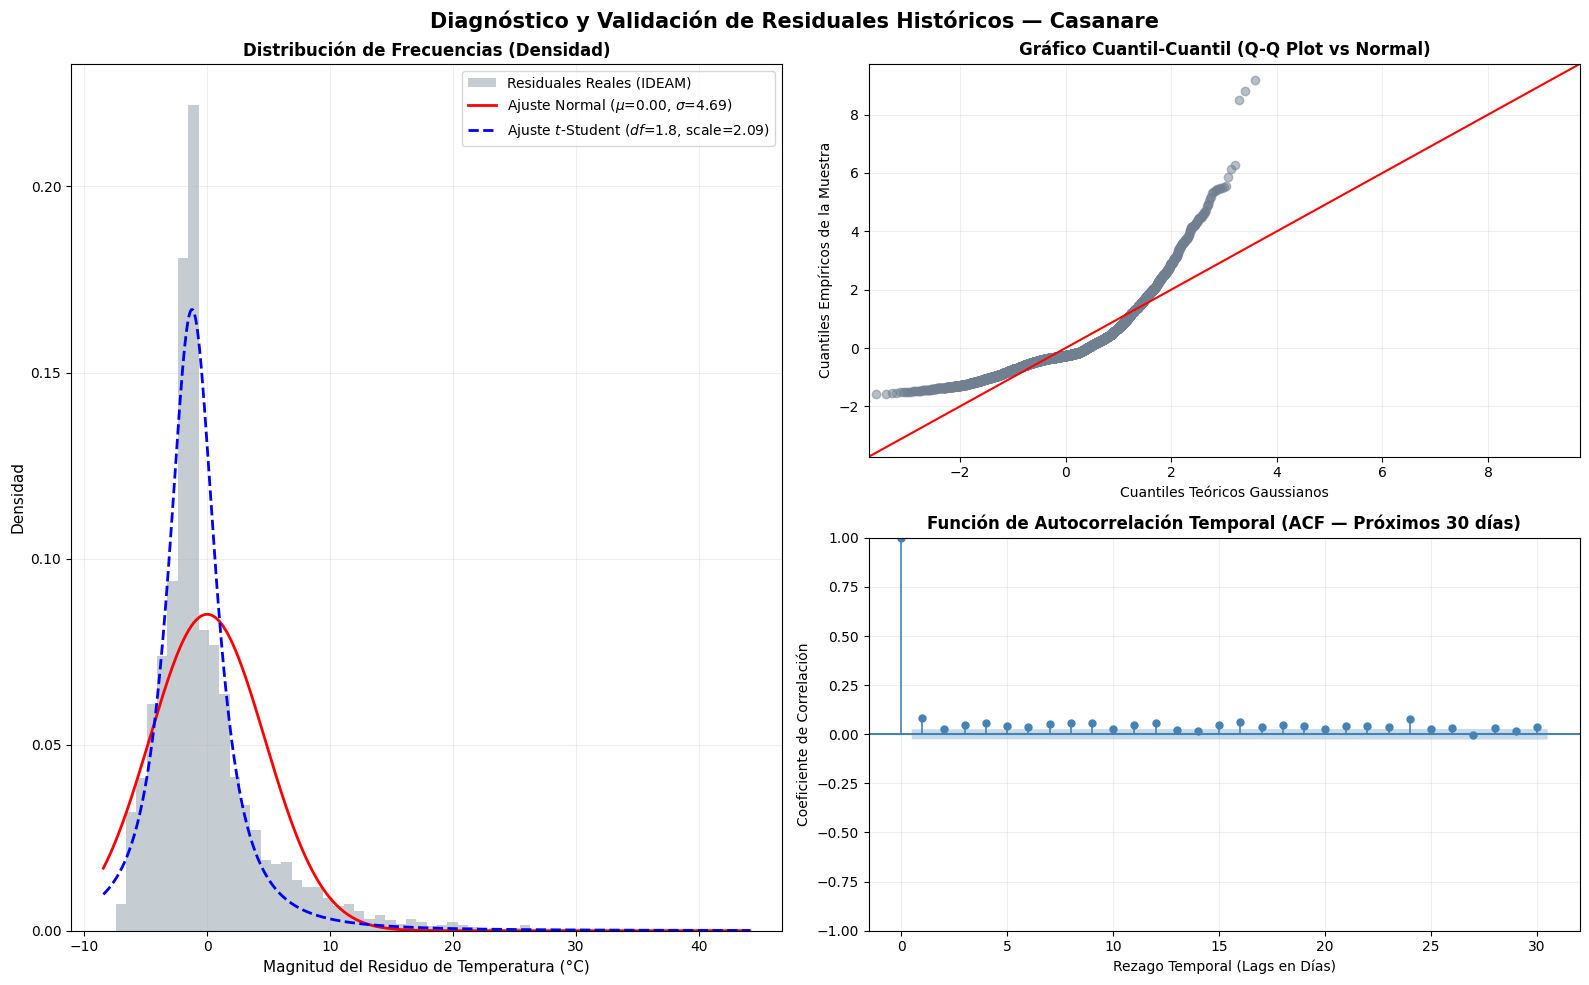


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES: TOLIMA

[1] Pruebas Estadísticas de Normalidad:
  - Jarque-Bera: Estadístico = 11246.8215, p-valor = 0.0000e+00
  - Shapiro-Wilk: Estadístico = 0.7769, p-valor = 5.5724e-67

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales climáticos presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos:
  - Ajuste Normal:    mu = 0.0000, sigma = 3.6666
  - Ajuste t-Student: df (Grados de libertad) = 1.41, loc = -1.5385, scale = 1.3659


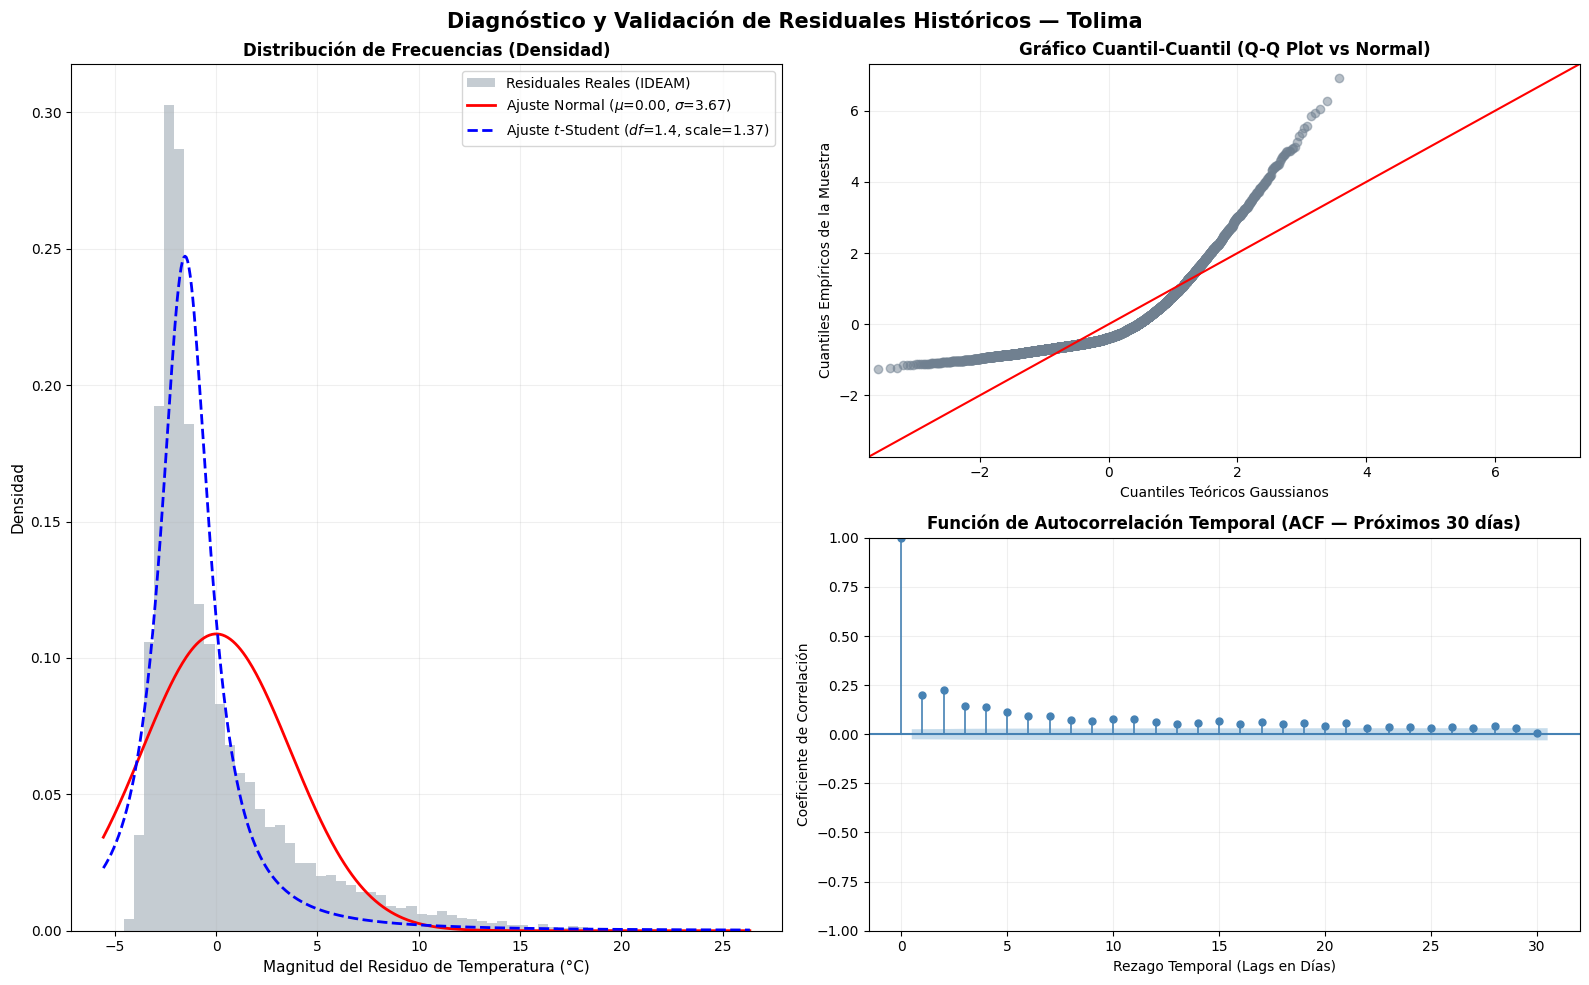

In [25]:
# =============================================================================
# FUNCIÓN DE VALIDACIÓN OPTIMIZADA (SIN WARNINGS)
# =============================================================================
def validar_residuales_alaton(df_dpto, nombre_dpto):
    print(f"\n" + "="*60)
    print(f" VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES: {nombre_dpto.upper()}")
    print("="*60)
    
    temp = df_dpto.copy()
    
    # 1. Reconstrucción del ajuste estacional diario
    temp['T_avg_calc'] = (temp['Temperature_Max_C'] + temp['Temperature_Min_C']) / 2
    dia_del_ano = temp.index.dayofyear
    temp['sin'] = np.sin(2 * np.pi * dia_del_ano / 365.25)
    temp['cos'] = np.cos(2 * np.pi * dia_del_ano / 365.25)
    
    y = temp['T_avg_calc']
    X = sm.add_constant(temp[['sin', 'cos']])
    
    model = sm.OLS(y, X).fit()
    residuals = (y - model.predict(X)).dropna()

    # =============================================================================
    # PRUEBAS FORMALES DE NORMALIDAD
    # =============================================================================
    print("\n[1] Pruebas Estadísticas de Normalidad:")
    
    # Prueba 1: Jarque-Bera
    jb_stat, jb_p_value = stats.jarque_bera(residuals)
    print(f"  - Jarque-Bera: Estadístico = {jb_stat:.4f}, p-valor = {jb_p_value:.4e}")
    
    # Prueba 2: Shapiro-Wilk (Silenciando de forma segura la advertencia de N > 5000)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, message=".*shapiro.*")
        shapiro_stat, shapiro_p_value = stats.shapiro(residuals)
    print(f"  - Shapiro-Wilk: Estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p_value:.4e}")
    
    if jb_p_value < 0.05 or shapiro_p_value < 0.05:
        print("\n  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).")
        print("      Los residuales climáticos presentan colas pesadas o asimetría. Se justifica usar t-Student.")
    else:
        print("\n  --> CONCLUSIÓN: No se rechaza la normalidad (p-valor >= 0.05). Los errores son Gaussianos.")

    # =============================================================================
    # AJUSTE DE DISTRIBUCIONES
    # =============================================================================
    mu_norm, sigma_norm = stats.norm.fit(residuals)
    df_t, loc_t, scale_t = stats.t.fit(residuals)
    
    print("\n[2] Parámetros de Ajuste Obtenidos:")
    print(f"  - Ajuste Normal:    mu = {mu_norm:.4f}, sigma = {sigma_norm:.4f}")
    print(f"  - Ajuste t-Student: df (Grados de libertad) = {df_t:.2f}, loc = {loc_t:.4f}, scale = {scale_t:.4f}")

    # =============================================================================
    # REPORTE GRÁFICO INTEGRADO
    # =============================================================================
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Diagnóstico y Validación de Residuales Históricos — {nombre_dpto}', fontsize=15, fontweight='bold')
    
    ax_hist = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax_qq = plt.subplot2grid((2, 2), (0, 1))
    ax_acf = plt.subplot2grid((2, 2), (1, 1))

    # --- PANEL 1: HISTOGRAMA ---
    ax_hist.hist(residuals, bins=60, density=True, alpha=0.4, color='slategrey', label='Residuales Reales (IDEAM)')
    x_axis = np.linspace(residuals.min() - 1, residuals.max() + 1, 500)
    
    normal_pdf = stats.norm.pdf(x_axis, loc=mu_norm, scale=sigma_norm)
    ax_hist.plot(x_axis, normal_pdf, color='red', lw=2, label=f'Ajuste Normal ($\mu$={mu_norm:.2f}, $\sigma$={sigma_norm:.2f})')
    
    t_pdf = stats.t.pdf(x_axis, df=df_t, loc=loc_t, scale=scale_t)
    ax_hist.plot(x_axis, t_pdf, color='blue', lw=2, ls='--', label=f'Ajuste $t$-Student ($df$={df_t:.1f}, scale={scale_t:.2f})')
    
    ax_hist.set_title('Distribución de Frecuencias (Densidad)', fontsize=12, fontweight='bold')
    ax_hist.set_xlabel('Magnitud del Residuo de Temperatura (°C)', fontsize=11)
    ax_hist.set_ylabel('Densidad', fontsize=11)
    ax_hist.grid(True, alpha=0.2)
    ax_hist.legend(loc='upper right', fontsize=10)

    # --- PANEL 2: Q-Q PLOT (CORREGIDO PARA EVITAR CONFLICTO DE COLOR) ---
    sm.qqplot(residuals, stats.norm, fit=True, line='45', ax=ax_qq, 
              markerfacecolor='slategrey', markeredgecolor='slategrey', alpha=0.5)
    ax_qq.get_lines()[1].set_color('red')
    ax_qq.get_lines()[1].set_linewidth(1.5)
    ax_qq.set_title('Gráfico Cuantil-Cuantil (Q-Q Plot vs Normal)', fontsize=12, fontweight='bold')
    ax_qq.set_xlabel('Cuantiles Teóricos Gaussianos', fontsize=10)
    ax_qq.set_ylabel('Cuantiles Empíricos de la Muestra', fontsize=10)
    ax_qq.grid(True, alpha=0.2)

    # --- PANEL 3: ACF ---
    plot_acf(residuals, ax=ax_acf, lags=30, color='steelblue', vlines_kwargs={"colors": 'steelblue', "linewidth": 1.2})
    ax_acf.set_title('Función de Autocorrelación Temporal (ACF — Próximos 30 días)', fontsize=12, fontweight='bold')
    ax_acf.set_xlabel('Rezago Temporal (Lags en Días)', fontsize=10)
    ax_acf.set_ylabel('Coeficiente de Correlación', fontsize=10)
    ax_acf.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
    
    dict_resultados = {
        'normal_params': (mu_norm, sigma_norm),
        't_params': (df_t, loc_t, scale_t),
        'rechaza_normalidad': (jb_p_value < 0.05)
    }
    return dict_resultados

# =============================================================================
# EJECUCIÓN DIRECTA EN EL NOTEBOOK
# =============================================================================
# Ejecutas la función pasándole tus dataframes filtrados por departamento
resultados_casanare = validar_residuales_alaton(df_Casanare, "Casanare")
resultados_tolima   = validar_residuales_alaton(df_Tolima, "Tolima")